In [ ]:
# using the Huggingface DRL course environment
%%capture
!apt install python-opengl
!apt install ffmpeg
!apt install xvfb
!pip install pyvirtualdisplay
!pip install pyglet==1.5.1

In [ ]:
%%capture
#!pip install -r https://raw.githubusercontent.com/huggingface/deep-rl-class/main/notebooks/unit4/requirements-unit4.txt
!pip install gymnasium
!pip install ale-py
!pip install imageio-ffmpeg
!pip install pyyaml==6.0

Install quantum related libraries.

In [ ]:
!pip install pennylane

## Imports

In [ ]:
import numpy as np

import json
from pathlib import Path
import datetime
from collections import deque
import os

import matplotlib.pyplot as plt
%matplotlib inline

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

from itertools import compress

# Gym
# import gym
import gymnasium as gym
from gymnasium import Wrapper
import ale_py

gym.register_envs(ale_py)
# import gym_pygame

# Hugging Face Hub
# from huggingface_hub import notebook_login # To log to our Hugging Face account to be able to upload models to the Hub.
import imageio

import pennylane as qml
import pennylane.numpy as pnp

In [ ]:
save_dir = "/content/drive/MyDrive/Research/PostDocProjects/QRL"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## Customised Pong Environment with 8 Features

These 8 features are:

- Paddle 1, edge 1 y value
- Paddle 1, centre y value
- Paddle 1, edge 2 y value
- Ball x value
- Ball y value
- Paddle 2, edge 1 y value
- Paddle 2, centre y value
- Paddle 2, edge 2 y value

In [ ]:
def extract_features(I):
  """
  Preprocess 210 x 6 x 3 uint8 frame into 8-dim vector
  """
  I = I[35:195]
  I = I[::2, ::2, 0]
  I[I==144] = 0
  I[I == 109] = 0
  I[I!=0] = 1
  x, y = np.where(I!=0)
  get_ball = (9<y) & (y<70)
  get_p1 = (y==9)
  get_p2 = (y==70)
  bx = list(compress(x,get_ball))
  by = list(compress(y,get_ball))
  Itran = I.transpose()
  if len(bx)!=0:
    by = np.mean(by)
    bx = np.mean(bx)
  else:
    bx, by = 0, 0
  p1f = list(compress(x,get_p1))
  p2f = list(compress(x,get_p2))
  if len(p1f)!=0:
      p1 = np.mean(np.array(p1f))
      p1e1 = np.max(np.array(p1f))
      p1e2 = np.min(np.array(p1f))
  else:
      p1 = 0
      p1e1 = 0
      p1e2 = 0
  if len(p2f)!=0:
      p2 = np.mean(p2f)
      p2e1 = np.max(p2f)
      p2e2 = np.min(p2f)
  else:
      p2 = 0
      p1e1 = 0
      p1e2 = 0
  return np.array([p1e1, p1, p1e2, bx, by, p2e1, p2, p2e2])/80

class CustomPongEnv(Wrapper):
    def __init__(self, env_name="PongDeterministic-v4"):
        # Initialize the base environment
        env = gym.make(env_name, render_mode="rgb_array")
        super().__init__(env)
        # Update observation space for the extracted features
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(8,), dtype=np.float32)

    def reset(self, **kwargs):
        # Reset the environment
        obs, info = self.env.reset(**kwargs)
        # Extract features
        features = extract_features(obs)
        return features, info

    def step(self, action):
        # Take a step in the environment
        obs, reward, terminated, truncated, info = self.env.step(action)
        # Extract features
        features = extract_features(obs)
        return features, reward, terminated, truncated, info

In [ ]:
# env_id = "PongDeterministic-v4"
# Create the env
env = CustomPongEnv()

# Create the evaluation env
eval_env = CustomPongEnv()

# Get the state space and action space
s_size = env.observation_space.shape[0]
a_size = env.action_space.n

In [ ]:
print("_____OBSERVATION SPACE_____ \n")
print("The State Space is: ", s_size)
print("Sample observation", env.observation_space.sample())  # Get a random observation

_____OBSERVATION SPACE_____ 

The State Space is:  8
Sample observation [-0.07019943  0.4614551   0.13955574  0.12722433 -1.098479   -0.19951372
  0.25468427 -1.0476223 ]


In [ ]:
print("\n _____ACTION SPACE_____ \n")
print("The Action Space is: ", a_size)
print("Action Space Sample", env.action_space.sample())  # Take a random action


 _____ACTION SPACE_____ 

The Action Space is:  6
Action Space Sample 2


## Quantum Policy

6


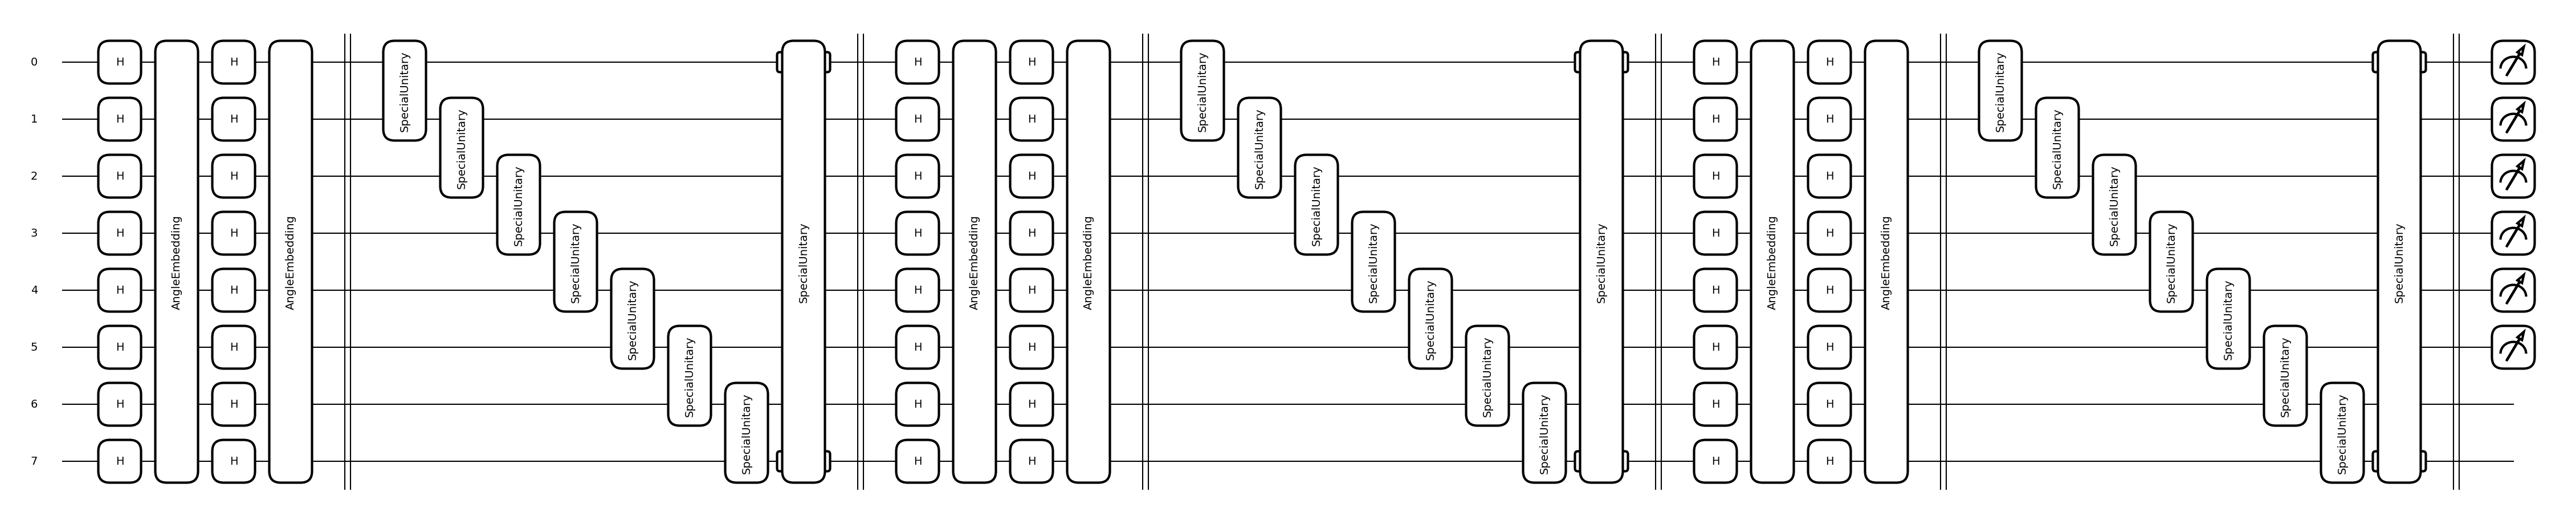

In [ ]:
def circular_su4(parameters, wires):
  # parameters have shape (num_qubits, 15)
  num_qubits = len(wires)
  for i in range(num_qubits):
    qml.SpecialUnitary(parameters[i], wires=[wires[(i+1)%num_qubits], wires[i]])

def z_featuremap(features, wires):
  for wire in wires:
    qml.Hadamard(wires=wire)
  qml.AngleEmbedding(features=features, wires=wires, rotation='Z')
  for wire in wires:
    qml.Hadamard(wires=wire)
  qml.AngleEmbedding(features=features, wires=wires, rotation='Z')

def data_encoding(features, omega, wires):
  transformed_features = omega * features
  z_featuremap(transformed_features, wires)

num_wires = 8
dev = qml.device("default.qubit", wires=num_wires)

@qml.qnode(dev, interface='torch')
def data_reuploading(theta, omega, features):
    """Define the QCNN circuit
    Args:
        theta (np.array): Shape (num_qubits, 15, L).
        omega (np.array): Shape (num_qubits,).
        features (np.array): Input data.
    """

    layers = theta.shape[-1]
    wires = list(range(num_wires))
    for i in range(layers):
      data_encoding(features, omega, wires)
      qml.Barrier(wires=wires, only_visual=True)
      circular_su4(theta[:,:,i], wires)
      qml.Barrier(wires=wires, only_visual=True)
    return [qml.expval(qml.PauliZ(i)) for i in range(6)]

test_output = data_reuploading(np.random.rand(num_wires, 15, 3), np.random.rand(num_wires), np.random.rand(num_wires))

print(len(test_output))

fig, ax = qml.draw_mpl(data_reuploading)(
    np.random.rand(num_wires, 15, 3), np.random.rand(num_wires), np.random.rand(num_wires)
)

plt.show()

In [ ]:
class QPolicy(nn.Module):
    def __init__(self, s_size, a_size, n_layers): # only work with s_size = 8 and a_size = 6
        super().__init__()
        self.n_layers = n_layers
        self.q_parameters = nn.ParameterList(
          [
            nn.Parameter(
                torch.rand(num_wires, 15, self.n_layers), requires_grad=True
            ), # theta
            nn.Parameter(
                torch.rand(num_wires), requires_grad=True
            ), # omega
          ]
        )


    def forward(self, x):
        expectation_vals = torch.concat(data_reuploading(self.q_parameters[0], self.q_parameters[1], x))
        return F.softmax(expectation_vals.reshape(-1,6), dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)

## REINFORCE Algorithm

Borrowing the image from Huggingface's DRL course:

![](https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit6/pg_pseudocode.png)

In [ ]:
def reinforce(policy, optimizer, n_training_episodes, max_t, gamma, print_every):
    # Help us to calculate the score during the training
    scores_deque = deque(maxlen=100)
    scores = []
    # Line 3 of pseudocode
    for i_episode in range(1, n_training_episodes + 1):
        saved_log_probs = []
        rewards = []
        state, _ = env.reset()
        # Line 4 of pseudocode
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Line 6 of pseudocode: calculate the return
        returns = deque(maxlen=max_t)
        n_steps = len(rewards)
        # Compute the discounted returns at each timestep,
        # as
        #      the sum of the gamma-discounted return at time t (G_t) + the reward at time t
        #
        # In O(N) time, where N is the number of time steps
        # (this definition of the discounted return G_t follows the definition of this quantity
        # shown at page 44 of Sutton&Barto 2017 2nd draft)
        # G_t = r_(t+1) + r_(t+2) + ...

        # Given this formulation, the returns at each timestep t can be computed
        # by re-using the computed future returns G_(t+1) to compute the current return G_t
        # G_t = r_(t+1) + gamma*G_(t+1)
        # G_(t-1) = r_t + gamma* G_t
        # (this follows a dynamic programming approach, with which we memorize solutions in order
        # to avoid computing them multiple times)

        # This is correct since the above is equivalent to (see also page 46 of Sutton&Barto 2017 2nd draft)
        # G_(t-1) = r_t + gamma*r_(t+1) + gamma*gamma*r_(t+2) + ...

        ## Given the above, we calculate the returns at timestep t as:
        #               gamma[t] * return[t] + reward[t]
        #
        ## We compute this starting from the last timestep to the first, in order
        ## to employ the formula presented above and avoid redundant computations that would be needed
        ## if we were to do it from first to last.

        ## Hence, the queue "returns" will hold the returns in chronological order, from t=0 to t=n_steps
        ## thanks to the appendleft() function which allows to append to the position 0 in constant time O(1)
        ## a normal python list would instead require O(N) to do this.
        for t in range(n_steps)[::-1]:
            disc_return_t = returns[0] if len(returns) > 0 else 0
            returns.appendleft(gamma * disc_return_t + rewards[t])

        ## standardization of the returns is employed to make training more stable
        eps = np.finfo(np.float32).eps.item()
        ## eps is the smallest representable float, which is
        # added to the standard deviation of the returns to avoid numerical instabilities
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + eps)

        # Line 7:
        policy_loss = []
        for log_prob, disc_return in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * disc_return)
        policy_loss = torch.cat(policy_loss).sum()

        # Line 8: PyTorch prefers gradient descent
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if i_episode % print_every == 0:
            print("Episode {}\tAverage Score: {:.2f}".format(i_episode, np.mean(scores_deque)))

    return scores

In [ ]:
hyperparameters = {
    "n_layers": 2,
    "n_training_episodes": 1000,
    "n_evaluation_episodes": 100,
    "max_t": 1000,
    "gamma": 0.99,
    "lr": 1e-3,
    "env_id": "CustomisedPongEightEleState",
    "state_space": int(s_size),
    "action_space": int(a_size),
}

policy = QPolicy(
    hyperparameters["state_space"],
    hyperparameters["action_space"],
    hyperparameters["n_layers"],
).to(device)

optimizer = optim.Adam(policy.parameters(), lr=hyperparameters["lr"])

In [ ]:
scores = reinforce(
    policy,
    optimizer,
    hyperparameters["n_training_episodes"],
    hyperparameters["max_t"],
    hyperparameters["gamma"],
    10,
)

Episode 10	Average Score: -20.40
Episode 20	Average Score: -20.50
Episode 30	Average Score: -20.13
Episode 40	Average Score: -20.20
Episode 50	Average Score: -20.22
Episode 60	Average Score: -20.32
Episode 70	Average Score: -20.36
Episode 80	Average Score: -20.36
Episode 90	Average Score: -20.21
Episode 100	Average Score: -20.24
Episode 110	Average Score: -20.26
Episode 120	Average Score: -20.21
Episode 130	Average Score: -20.27
Episode 140	Average Score: -20.28
Episode 150	Average Score: -20.28
Episode 160	Average Score: -20.21
Episode 170	Average Score: -20.07
Episode 180	Average Score: -19.95
Episode 190	Average Score: -20.01
Episode 200	Average Score: -19.91
Episode 210	Average Score: -19.87
Episode 220	Average Score: -19.86
Episode 230	Average Score: -19.89
Episode 240	Average Score: -19.83
Episode 250	Average Score: -19.73
Episode 260	Average Score: -19.68
Episode 270	Average Score: -19.77
Episode 280	Average Score: -19.85
Episode 290	Average Score: -19.93
Episode 300	Average Sco

In [ ]:
def evaluate_agent(env, max_steps, n_eval_episodes, policy):
    """
    Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
    :param env: The evaluation environment
    :param n_eval_episodes: Number of episode to evaluate the agent
    :param policy: The Reinforce agent
    """
    episode_rewards = []
    for episode in range(n_eval_episodes):
        state,_ = env.reset()
        step = 0
        done = False
        total_rewards_ep = 0

        for step in range(max_steps):
            action, _ = policy.act(state)
            new_state, reward, done, info,_ = env.step(action)
            total_rewards_ep += reward

            if done:
                break
            state = new_state
        episode_rewards.append(total_rewards_ep)
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)

    return mean_reward, std_reward

In [ ]:
evaluate_agent(
    eval_env, hyperparameters["max_t"], hyperparameters["n_evaluation_episodes"], policy
)

In [ ]:
def record_video(env, policy, out_directory, fps=30):
    """
    Generate a replay video of the agent
    :param env
    :param Qtable: Qtable of our agent
    :param out_directory
    :param fps: how many frame per seconds (with taxi-v3 and frozenlake-v1 we use 1)
    """
    images = []
    done = False
    state,_ = env.reset()
    img = env.render()
    images.append(img)
    while not done:
        # Take the action (index) that have the maximum expected future reward given that state
        action, _ = policy.act(state)
        state, reward, done, info,_ = env.step(action)  # We directly put next_state = state for recording logic
        img = env.render()
        images.append(img)
    imageio.mimsave(out_directory, [np.array(img) for i, img in enumerate(images)], fps=fps)

In [ ]:
local_directory = Path(save_dir)
with open(local_directory / "hyperparameters_quantum.json", "w") as outfile:
  json.dump(hyperparameters, outfile)

mean_reward, std_reward = evaluate_agent(eval_env,
                                        hyperparameters["max_t"],
                                        hyperparameters["n_evaluation_episodes"],
                                        policy)
eval_datetime = datetime.datetime.now()
eval_form_datetime = eval_datetime.isoformat()
evaluate_data = {
          "env_id": hyperparameters["env_id"],
          "mean_reward": mean_reward,
          "n_evaluation_episodes": hyperparameters["n_evaluation_episodes"],
          "eval_datetime": eval_form_datetime,
}
with open(local_directory / "results_quantum.json", "w") as outfile:
  json.dump(evaluate_data, outfile)

video_path =  local_directory / "replay_quantum.mp4"
record_video(env, policy, video_path, 30)